In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import HuggingFaceEndpoint ,ChatHuggingFace
from langchain_core.utils.function_calling import convert_to_openai_tool
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from typing import TypedDict,Literal,Annotated
from pydantic import BaseModel,Field
from dotenv import load_dotenv
load_dotenv() 

True

In [2]:
generator_llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="text-generation",
    
)
# 2. Evaluator
evaluator_llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="text-generation",
    
)
# 3. Polisher
polisher_llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="text-generation",
    
)
model_1 = ChatHuggingFace(llm=generator_llm)
model_2 = ChatHuggingFace(llm=evaluator_llm)
model_3 = ChatHuggingFace(llm=polisher_llm) 

In [3]:
class TweetEvalution(BaseModel):
    evaluation:Literal["approved","need_polishe"] = Field(description=" Final evaluation result")
    feedback:str=Field(description=" Constructive feedback for tweet")
schema_dict = convert_to_openai_tool(TweetEvalution)
Structure_evluation =model_2.with_structured_output(schema_dict)

In [4]:
class poststate(TypedDict):
    topic: str
    tweet: str
    evulution:Literal["approved","need_polishe"]
    polished: str
    feedback: str
    iteration: int

In [5]:
def generate_tweet(state:poststate):
    #prompt for generating a tweet
    messages = [
    SystemMessage(content="You are a funny and clever Twitter/X influencer."),
    HumanMessage(content=f"""
    Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

    Rules:
    - Do NOT use question-answer format.
    - Max 280 characters.
    - Use observational humor, irony, sarcasm, or cultural references.
    - Think in meme logic, punchlines, or relatable takes.
    - Use simple, day to day english
    """)
    ]
    response = model_1.invoke(messages).content
    return{ "tweet": response}

In [6]:
def evaluate_tweet(state:poststate):
    messages = [
    SystemMessage(
        content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."
    ),
    HumanMessage(content=f"""
    Evaluate the following tweet:

    Tweet: "{state['tweet']}"

    Use the criteria below to evaluate the tweet:

    1. Originality - Is this fresh, or have you seen it a hundred times before?
    2. Humor - Did it genuinely make you smile, laugh, or chuckle?
    3. Punchiness - Is it short, sharp, and scroll-stopping?
    4. Virality Potential - Would people retweet or share it?
    5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

    Auto-reject if:
    - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
    - It exceeds 280 characters
    - It reads like a traditional setup-punchline joke
    - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., "Masterpieces of the auntie-uncle universe") or vague summaries

    ### Respond ONLY in structured format:
    - evaluation: "approved" or "needs improvement"
    - feedback: One paragraph explaining the strengths and weaknesses
    """)
]
    response =Structure_evluation.invoke(messages)

    return{'evulution': response['evaluation'] , 'feedback':response['feedback']}


In [7]:
def tweet_polishing(state:poststate):
    message =  [
    SystemMessage(
        content="You punch up tweets for virality and humor based on given feedback."
    ),
    HumanMessage(content=f"""
    Improve the tweet based on this feedback:
    "{state['feedback']}"

    Topic: "{state['topic']}"
    Original Tweet:
    {state['tweet']}

    Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
    """)
    ]
    response = model_3.invoke(message).content
    iteration =state['iteration']+1

    return{'tweet': response, 'iteration': iteration}

In [8]:
def evaluation(state:poststate):
    if state['evulution']== 'approved':
        return 'approved'
    else:
        return 'need_polishe'



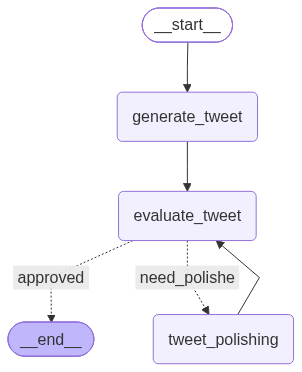

In [9]:
graph = StateGraph(poststate)
#define nodes
graph.add_node("generate_tweet",generate_tweet)
graph.add_node("evaluate_tweet",evaluate_tweet)
graph.add_node("tweet_polishing",tweet_polishing)

#define ege 
graph.add_edge(START,"generate_tweet")
graph.add_edge("generate_tweet","evaluate_tweet")
graph.add_conditional_edges(
    "evaluate_tweet",
    evaluation,
    {
        'approved': END,
        'need_polishe': "tweet_polishing",
    },
)
graph.add_edge("tweet_polishing","evaluate_tweet")

graph.compile()


In [10]:
workflow=graph.compile()
initial_State = {
    "topic":"july movement in Bangladesh",
    "iteration":1
}
result = workflow.invoke(initial_State)

In [ ]:
print(result.get("tweet"))
print(type(result))